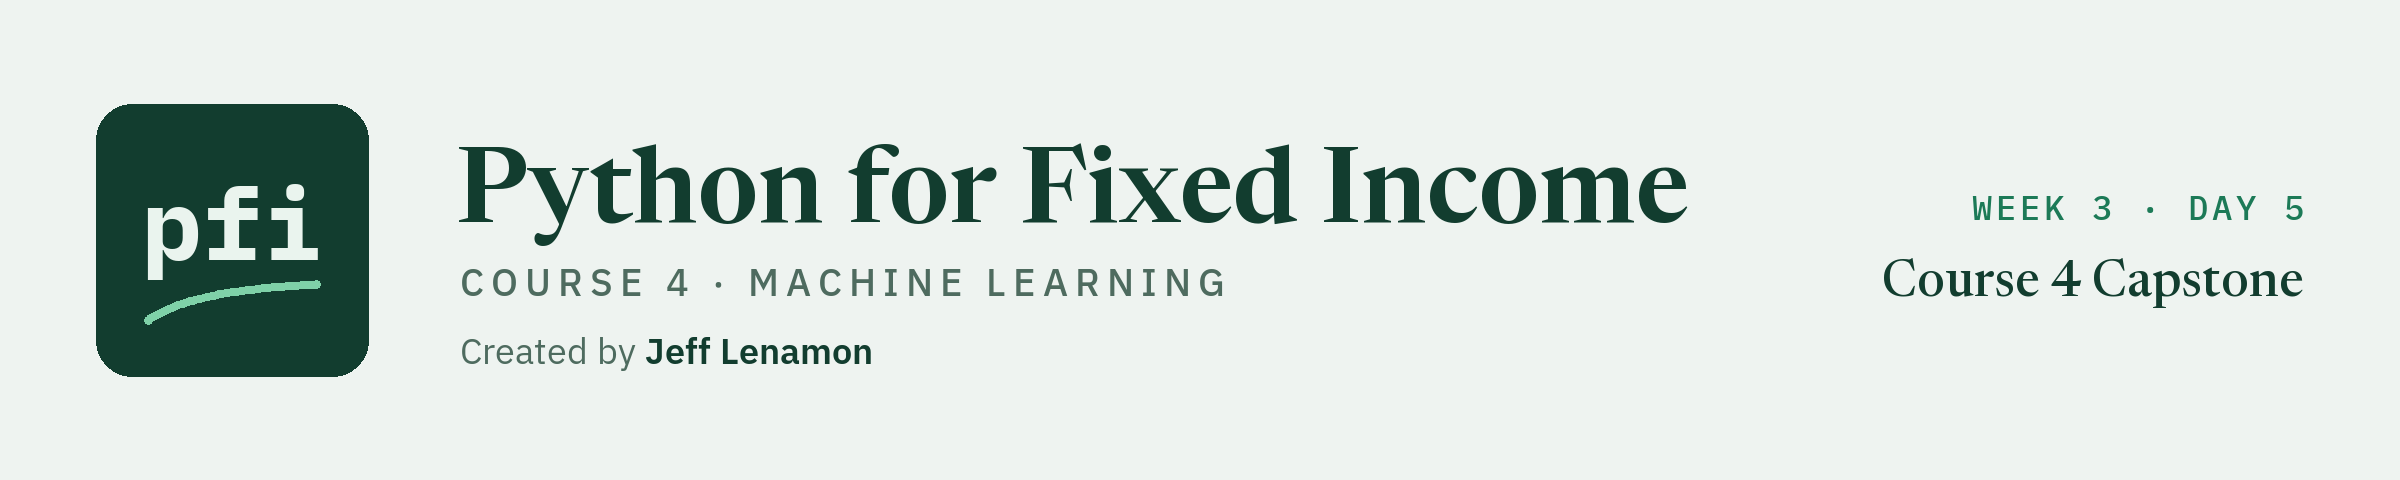

# Course 4 Capstone

Week 3, Day 5. A real file of Polish company statements, checked against its source, described before any split, prepared without a leak, and modelled three ways: a logistic regression and two pruned trees, chosen on training folds, tested once, written to Excel and Git, and described with what the model shows and where it fails. You write the code.

**Data:** `polish_bankruptcy_5year.csv`, 5,910 financial statements of Polish companies: **real**, UCI Machine Learning Repository dataset 365, CC BY 4.0. Citation: Tomczak, S. (2016). Polish Companies Bankruptcy [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F600.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week3/day5/course4_capstone.ipynb)

## The Brief

### The scenario

A colleague who covers emerging market corporates hands you a public file: financial ratios from the annual statements of Polish companies, each statement flagged by whether the company went bankrupt in the following year. The question: **which of three standard models separates the statements of companies that went bankrupt, how well on rows it never saw, and where does it fail?**

Fourteen days built the tools: `mlkit.py`, tested against Excel and scikit-learn, the split that keeps test rows away, pipelines that fit every step on training rows only, thresholds chosen for a recall, trees and their pruning, and Git as an experiment log. Today you use all of them on one dataset you have not seen.

The answer is a description of a historical, anonymised dataset. It is not a credit view on any company, and nothing you build is a rating, a credit decision, or a probability of default for any company going forward.

### What makes it hard

Nothing is planted. The file is the real one, as the provider published it, and it has what real files have: missing values, exact duplicate rows, a rare outcome, and features on very different scales, some with extreme values. Finding each one, saying what you do about it, and doing it without letting the test rows leak into training is the work.

### What to hand in

This notebook, completed and run from top to bottom, with twelve deliverables:

| # | Deliverable | Where |
| --- | --- | --- |
| 1 | `mlkit.py` complete, and `pytest -q` passing with its output saved | Section 1 |
| 2 | `load_bankruptcy(path)` in `bankruptcy.py`: reads the file, checks it, returns the frame with a check log | Section 2 |
| 3 | A description of the whole file in hashed checks: rows, bankruptcies, missing cells, duplicates, the largest values | Section 3 |
| 4 | `prepare(frame)`: drops exact duplicates, splits 80/20 stratified with `SEED`, and asserts `assert_disjoint` | Section 4 |
| 5 | Three models as functions that return unfitted pipelines, compared by cross-validation on the training rows | Section 5 |
| 6 | A threshold for each model for a recall of 0.70, from out-of-fold probabilities on the training rows | Section 6 |
| 7 | The test rows opened once: `compare_models` and each model's confusion matrix | Section 8 |
| 8 | A final choice, with reasons | Sections 7 and 8 |
| 9 | A results workbook, `course4_capstone_results.xlsx`, read back and checked | Section 9 |
| 10 | A written description, "What the model shows, and where it fails", that passes `assert_descriptive` | Section 10 |
| 11 | One Git commit for each deliverable that writes a file, then the tag `course4` | Every section, then Save the Day with Git |
| 12 | An AI-use log | Section 10 |

### How long

The course map gives the capstone one day. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 the module, 2 load and check, 3 the whole file, 4 prepare |
| Second | 5 three models, 6 thresholds, 7 the choice |
| Third | 8 the test rows, 9 the workbook, 10 the description and the log, then Git and Bring It Home |

### The rules

1. **`frame` is the file as it arrived** and is never changed. Every step makes a new table.
2. **Description before the split, modelling after it.** Section 3 describes the whole file, and no number from it builds a feature. From section 4 on, the split comes first.
3. **Every preprocessing step lives inside a pipeline** and is fitted on training rows only: the imputer's medians, the quantile transform, the indicators.
4. **Three roles of rows.** Training rows fit. Folds of the training rows choose: the hyperparameters, the thresholds, and the model. The test rows report, once, in section 8, after the choice is written down.
5. **`random_state=SEED` on everything that takes one.** The setup cell sets one thread before the libraries load, so every run prints the same numbers.
6. **Describe, never forecast.** Every sentence you write says what a model shows on this file and where it fails. Nothing says a company, or a kind of company, is a good or bad credit, and nothing says what a lender or an investor should do.
7. **Git only in the work folder.** Every Git command is written `!git -C "{work}" ...`, as on every day of the course.
8. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

Every earlier notebook of the course and your notes; the documentation of pandas, scikit-learn, and openpyxl; and an AI assistant, used the way the course taught: the docstring is the prompt, read the code that comes back, test it before you trust it, and keep a log as you go (question 10.5). Nothing from an employer goes into an AI tool or into Colab.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_2_1`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. The right answers are not written anywhere in this notebook: each check holds a short code made from the right answer, and `check()` makes a code from yours in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the places the question states before it is compared, so store the full number and let `check()` round it. Text is compared without regard to capitals or spaces at the ends. Several values go in a tuple, in the order the question asks.

Your decisions change the numbers that follow, so the checks after section 4 assume the decisions the course made. Under some questions a closed block that starts "Stuck after trying?" holds the decision the capstone expects for one kind of choice: not a count and not an answer. Leave it closed until you have made your own.

Worked answers are in `course4_capstone_solutions.ipynb` in this folder. Open it after you have written your own description.

## The Data

**The source.** UCI Machine Learning Repository, dataset 365, "Polish Companies Bankruptcy", created by Sebastian Tomczak and donated to the repository in 2016: https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data . Licence, quoted from the page: "This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license. This allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given." Citation, as the page gives it: Tomczak, S. (2016). Polish Companies Bankruptcy [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F600.

**What the page says about the companies,** quoted: "The data was collected from Emerging Markets Information Service (EMIS, http://www.securities.com), which is a database containing information on emerging markets around the world. The bankrupt companies were analyzed in the period 2000-2012, while the still operating companies were evaluated from 2007 to 2013." The zip on the page holds five files; the course uses the fifth, whose statements come from the last year before the outcome, and whose label says whether the company went bankrupt one year later. The page gives that file 5,910 statements, 410 of them from companies that went bankrupt. Company names are not in the data.

**What the course changed,** the only changes, as the licence asks they be stated: the provider's ARFF file was written as `polish_bankruptcy_5year.csv`; the missing marker `?` became an empty cell; `class` became the whole number 0 or 1; every other value was written back exactly. The exact duplicate rows are still in the file. Nothing was recoded, corrected, sorted, or dropped.

**Place and period.** One country's companies, 2000 to 2013. The market, the accounting rules, and the bankruptcy law differ from US corporate credit, as the card file of week 2 differed from US consumer credit.

**Names.** The file names its features `Attr1` to `Attr64`; the page defines them as X1 to X64 and does not state the mapping. The course reads `Attr`k as Xk, in order, with evidence from the file itself that question 3.10 tests. Not every feature is a unitless ratio: X29 is a logarithm of total assets (the page does not state the base), X55 is working capital, an amount in a currency the page does not state, and nine features (X5, X15, X20, X32, X43, X44, X47, X52, X62) are multiplied by 365, so they read in days. The setup's `describe_feature` writes a feature both ways.

**The data dictionary,** the page's definitions word for word:

| File column | Page name | Definition |
| --- | --- | --- |
| `Attr1` | X1 | net profit / total assets |
| `Attr2` | X2 | total liabilities / total assets |
| `Attr3` | X3 | working capital / total assets |
| `Attr4` | X4 | current assets / short-term liabilities |
| `Attr5` | X5 | [(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] \* 365 |
| `Attr6` | X6 | retained earnings / total assets |
| `Attr7` | X7 | EBIT / total assets |
| `Attr8` | X8 | book value of equity / total liabilities |
| `Attr9` | X9 | sales / total assets |
| `Attr10` | X10 | equity / total assets |
| `Attr11` | X11 | (gross profit + extraordinary items + financial expenses) / total assets |
| `Attr12` | X12 | gross profit / short-term liabilities |
| `Attr13` | X13 | (gross profit + depreciation) / sales |
| `Attr14` | X14 | (gross profit + interest) / total assets |
| `Attr15` | X15 | (total liabilities \* 365) / (gross profit + depreciation) |
| `Attr16` | X16 | (gross profit + depreciation) / total liabilities |
| `Attr17` | X17 | total assets / total liabilities |
| `Attr18` | X18 | gross profit / total assets |
| `Attr19` | X19 | gross profit / sales |
| `Attr20` | X20 | (inventory \* 365) / sales |
| `Attr21` | X21 | sales (n) / sales (n-1) |
| `Attr22` | X22 | profit on operating activities / total assets |
| `Attr23` | X23 | net profit / sales |
| `Attr24` | X24 | gross profit (in 3 years) / total assets |
| `Attr25` | X25 | (equity - share capital) / total assets |
| `Attr26` | X26 | (net profit + depreciation) / total liabilities |
| `Attr27` | X27 | profit on operating activities / financial expenses |
| `Attr28` | X28 | working capital / fixed assets |
| `Attr29` | X29 | logarithm of total assets |
| `Attr30` | X30 | (total liabilities - cash) / sales |
| `Attr31` | X31 | (gross profit + interest) / sales |
| `Attr32` | X32 | (current liabilities \* 365) / cost of products sold |
| `Attr33` | X33 | operating expenses / short-term liabilities |
| `Attr34` | X34 | operating expenses / total liabilities |
| `Attr35` | X35 | profit on sales / total assets |
| `Attr36` | X36 | total sales / total assets |
| `Attr37` | X37 | (current assets - inventories) / long-term liabilities |
| `Attr38` | X38 | constant capital / total assets |
| `Attr39` | X39 | profit on sales / sales |
| `Attr40` | X40 | (current assets - inventory - receivables) / short-term liabilities |
| `Attr41` | X41 | total liabilities / ((profit on operating activities + depreciation) \* (12/365)) |
| `Attr42` | X42 | profit on operating activities / sales |
| `Attr43` | X43 | rotation receivables + inventory turnover in days |
| `Attr44` | X44 | (receivables \* 365) / sales |
| `Attr45` | X45 | net profit / inventory |
| `Attr46` | X46 | (current assets - inventory) / short-term liabilities |
| `Attr47` | X47 | (inventory \* 365) / cost of products sold |
| `Attr48` | X48 | EBITDA (profit on operating activities - depreciation) / total assets |
| `Attr49` | X49 | EBITDA (profit on operating activities - depreciation) / sales |
| `Attr50` | X50 | current assets / total liabilities |
| `Attr51` | X51 | short-term liabilities / total assets |
| `Attr52` | X52 | (short-term liabilities \* 365) / cost of products sold) |
| `Attr53` | X53 | equity / fixed assets |
| `Attr54` | X54 | constant capital / fixed assets |
| `Attr55` | X55 | working capital |
| `Attr56` | X56 | (sales - cost of products sold) / sales |
| `Attr57` | X57 | (current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation) |
| `Attr58` | X58 | total costs /total sales |
| `Attr59` | X59 | long-term liabilities / equity |
| `Attr60` | X60 | sales / inventory |
| `Attr61` | X61 | sales / receivables |
| `Attr62` | X62 | (short-term liabilities \*365) / sales |
| `Attr63` | X63 | sales / short-term liabilities |
| `Attr64` | X64 | sales / fixed assets |
| `class` | | 1 if the company went bankrupt in the year after the statement, 0 if not |

## Setup

Run the setup cells first. They are complete: do not change them. The first makes today's work folder and copies the data files into it: the bankruptcy file, and the five files the module's tests read. The next two write the complete `mlkit.py` and `test_mlkit.py` as day 14 left them: 21 functions and 56 tests. **If you kept your own `my_bondmath` up to date, paste your own two files into those cells instead.** Then the module is imported, and the last setup cell defines `describe_feature()`, `reload_capstone()`, `answer_text()`, and `check()`.

Q. Set up the work folder and copy the data files into it.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_15_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv", "treasury_par_yields.csv", "polish_bankruptcy_5year.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_15_nsulq6ei, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv, treasury_par_yields.csv, polish_bankruptcy_5year.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as day 14 left them: the complete module.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)


from sklearn.model_selection import KFold, StratifiedKFold


def test_cv_folds_classification_is_stratified():
    folds = mlkit.cv_folds()
    assert isinstance(folds, StratifiedKFold)
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)
    X_train, _, _, y_train, _, _ = card_split()
    overall = y_train.mean()
    for train_positions, test_positions in folds.split(X_train, y_train):
        mlkit.assert_disjoint(train_positions, test_positions)
        # each fold keeps the training rows' default rate to within one account
        assert abs(y_train.iloc[test_positions].mean() - overall) < 1 / len(test_positions) + 1e-12


def test_cv_folds_regression():
    folds = mlkit.cv_folds("regression")
    assert type(folds) is KFold
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)


def test_cv_folds_rejects_unknown():
    with pytest.raises(ValueError, match="time"):
        mlkit.cv_folds("time")


from sklearn.exceptions import NotFittedError
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier


def fitted_models() -> tuple[dict, pd.DataFrame, pd.Series]:
    """A scaled logistic regression and a depth-3 balanced tree fitted on the card training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    models = {
        "logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        "tree": DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED),
    }
    for model in models.values():
        model.fit(X_train, y_train)
    return models, X_valid, y_valid


def test_compare_models_columns():
    models, X_valid, y_valid = fitted_models()
    table = mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    assert list(table.index) == ["logistic", "tree"]
    assert list(table.columns) == ["roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall",
                                   "f1"]
    proba = models["logistic"].predict_proba(X_valid)[:, 1]
    assert table.loc["logistic", "roc_auc"] == pytest.approx(roc_auc_score(y_valid, proba), abs=1e-12)
    assert table.loc["logistic", "average_precision"] == pytest.approx(average_precision_score(y_valid, proba),
                                                                         abs=1e-12)
    flags = (proba >= 0.2).astype(int)
    assert table.loc["logistic", "recall"] == pytest.approx(recall_score(y_valid, flags), abs=1e-12)
    with pytest.raises(ValueError, match="tree"):
        mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2})


def test_compare_models_does_not_refit():
    models, X_valid, y_valid = fitted_models()
    before = models["logistic"]["model"].coef_.copy()
    mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    # the coefficients learned on the training rows are untouched
    assert np.array_equal(models["logistic"]["model"].coef_, before)
    # and a model nobody fitted is refused, not fitted on the rows given
    with pytest.raises(NotFittedError):
        mlkit.compare_models({"new": LogisticRegression()}, X_valid, y_valid, {"new": 0.5})


def test_assert_descriptive_passes_plain_text():
    mlkit.assert_descriptive("In this file the model ranked 72 percent of default and non-default pairs correctly. "
                             "A willing reader can check every number.")


def test_assert_descriptive_names_the_word():
    with pytest.raises(ValueError, match=r"\['will', 'cheap'\]"):
        mlkit.assert_descriptive("These bonds look Cheap and spreads WILL tighten.")


from sklearn.model_selection import TimeSeriesSplit


def treasury_dates() -> pd.DatetimeIndex:
    """The 2,940 dates of the Treasury par yield file, 2015-01-02 to 2026-10-02."""
    return pd.DatetimeIndex(pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"])["date"])


def test_walk_forward_hand_index():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2)
    expected = [([0, 1, 2, 3], [4, 5]), ([0, 1, 2, 3, 4, 5], [6, 7]), ([0, 1, 2, 3, 4, 5, 6, 7], [8, 9])]
    assert [(train.tolist(), test.tolist()) for train, test in splits] == expected
    # a last window of one row is dropped
    assert len(mlkit.walk_forward_splits(dates[:9], min_train=4, test_size=2)) == 2


def test_walk_forward_gap():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2, gap=1)
    assert [(train.tolist(), test.tolist()) for train, test in splits] == [
        ([0, 1, 2, 3], [5, 6]), ([0, 1, 2, 3, 4, 5], [7, 8])]
    for train, test in splits:
        mlkit.assert_past_only(dates[train], dates[test], gap=1, calendar=dates)
    # scikit-learn's TimeSeriesSplit with the same test size and gap gives the same positions
    ours = mlkit.walk_forward_splits(dates, min_train=5, test_size=2, gap=1)
    library = TimeSeriesSplit(n_splits=2, test_size=2, gap=1).split(np.zeros(len(dates)))
    assert [(a.tolist(), b.tolist()) for a, b in ours] == [(a.tolist(), b.tolist()) for a, b in library]


def test_walk_forward_past_only():
    dates = treasury_dates()
    # about two years to start, about six months per test window
    splits = mlkit.walk_forward_splits(dates, min_train=504, test_size=126)
    assert len(splits) == (len(dates) - 504) // 126
    for train, test in splits:
        mlkit.assert_disjoint(train, test)
        mlkit.assert_past_only(dates[train], dates[test])
        assert len(test) == 126


def test_walk_forward_rejects_unsorted():
    dates = pd.DatetimeIndex(["2026-01-06", "2026-01-05", "2026-01-07", "2026-01-08"])
    with pytest.raises(ValueError, match="ascending"):
        mlkit.walk_forward_splits(dates, min_train=2, test_size=1)
    with pytest.raises(ValueError, match="unique"):
        mlkit.walk_forward_splits(pd.DatetimeIndex(["2026-01-05"] * 4), min_train=2, test_size=1)


def test_assert_past_only_raises():
    dates = treasury_dates()
    # a shuffled split puts later dates in training: it is refused
    shuffled = KFold(5, shuffle=True, random_state=SEED)
    train, test = next(shuffled.split(np.zeros(len(dates))))
    with pytest.raises(AssertionError, match="not before"):
        mlkit.assert_past_only(dates[train], dates[test])
    # a gap of 5 rows asked for, 0 given
    with pytest.raises(AssertionError, match="gap of 5"):
        mlkit.assert_past_only(dates[:100], dates[100:110], gap=5, calendar=dates)
    with pytest.raises(ValueError, match="calendar"):
        mlkit.assert_past_only(dates[:100], dates[105:110], gap=5)


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def scaled_bonds() -> np.ndarray:
    """log_oas, duration, coupon, and rating score of the 821 bonds, each scaled to mean 0 and standard deviation 1
    (StandardScaler, fitted on every bond: nothing is tested on held-out rows when clustering)."""
    bench = read_bench()
    return StandardScaler().fit_transform(bench[["log_oas", "duration", "coupon", "score"]])


def test_elbow_table_columns_and_ks():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert list(table.index) == list(range(2, 9))
    assert table.index.name == "k"
    assert list(table.columns) == ["inertia", "silhouette"]
    assert table["silhouette"].between(-1, 1).all()
    with pytest.raises(ValueError):
        mlkit.elbow_table(scaled_bonds(), [1, 3])


def test_elbow_inertia_decreases():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert table["inertia"].is_monotonic_decreasing


def test_elbow_matches_kmeans():
    X = scaled_bonds()
    table = mlkit.elbow_table(X, [4])
    model = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X)
    assert table.loc[4, "inertia"] == pytest.approx(model.inertia_, abs=1e-9)
    assert table.loc[4, "silhouette"] == pytest.approx(silhouette_score(X, model.labels_), abs=1e-12)


def test_cluster_profile_counts():
    frame = pd.DataFrame({"oas": [100.0, 120.0, 400.0, 500.0, 600.0]})
    profile = mlkit.cluster_profile(frame, [0, 0, 1, 1, 1], ["oas"])
    assert profile.index.name == "cluster"
    assert profile["count"].tolist() == [2, 3]
    assert profile["oas"].tolist() == [110.0, 500.0]


def test_cluster_profile_original_units():
    bench = read_bench()
    labels = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(scaled_bonds()).labels_
    profile = mlkit.cluster_profile(bench, labels, ["oas", "duration"])
    assert profile["count"].sum() == len(bench)
    for k in profile.index:
        # medians in bp and years, from the unscaled rows
        assert profile.loc[k, "oas"] == bench.loc[labels == k, "oas"].median()
        assert profile.loc[k, "duration"] == bench.loc[labels == k, "duration"].median()
    # in bp, not in scaled units: every median spread is a positive number of bp
    assert (profile["oas"] > 10).all()


def test_cluster_profile_length_mismatch_raises():
    frame = pd.DataFrame({"oas": [100.0, 120.0, 400.0]})
    with pytest.raises(ValueError, match="labels has 2 values"):
        mlkit.cluster_profile(frame, [0, 1], ["oas"])
    with pytest.raises(ValueError, match="duration"):
        mlkit.cluster_profile(frame, [0, 1, 1], ["duration"])


from sklearn.decomposition import PCA

TENORS = ["1 Yr", "2 Yr", "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr", "30 Yr"]


def curve_changes() -> pd.DataFrame:
    """Daily changes in bp of the 1 Yr to 30 Yr Treasury par yields, indexed by date."""
    curve = pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")
    return (curve[TENORS].diff() * 100).dropna()


def window_scores(changes: pd.DataFrame) -> pd.DataFrame:
    """Fit a 3-component PCA on the rows given and return their scores with the sign-fixed loadings."""
    pca = PCA(n_components=3).fit(changes)
    loadings = mlkit.pca_loadings(pca, list(changes.columns))
    return (changes - pca.mean_) @ loadings


def test_pca_loadings_sign_rule():
    changes = curve_changes()
    pca = PCA(n_components=3).fit(changes)
    loadings = mlkit.pca_loadings(pca, TENORS)
    assert list(loadings.columns) == ["PC1", "PC2", "PC3"]
    assert (loadings.sum(axis=0) > 0).all()
    # flipping a component's sign by hand gives the same loadings back
    pca.components_[1] *= -1
    pd.testing.assert_frame_equal(mlkit.pca_loadings(pca, TENORS), loadings)
    with pytest.raises(ValueError):
        mlkit.pca_loadings(pca, TENORS[:3])


def test_explained_table_sums():
    changes = curve_changes()
    table = mlkit.explained_table(PCA().fit(changes))
    assert table["cumulative_pct"].iloc[-1] == pytest.approx(100.0, abs=1e-9)
    assert table["cumulative_pct"].to_numpy() == pytest.approx(np.cumsum(table["explained_pct"]), abs=1e-12)
    assert table["explained_pct"].is_monotonic_decreasing


def test_pca_scores_no_lookahead():
    changes = curve_changes()
    t = changes.index[1500]
    # a PCA fitted on rows up to t, scored on those rows
    window = window_scores(changes.loc[:t])
    # the same, after removing every row after t from the data: nothing changes
    cut = changes[changes.index <= t]
    pd.testing.assert_frame_equal(window_scores(cut), window, check_exact=True)
    # fitted on the whole history, the scores of the same dates differ: that is lookahead
    whole = window_scores(changes).loc[:t]
    assert not np.allclose(whole.to_numpy(), window.to_numpy(), rtol=0, atol=1e-6)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall', 'cv_folds', 'compare_models', 'assert_descriptive', 'walk_forward_splits', 'assert_past_only', 'elbow_table', 'cluster_profile', 'pca_loadings', 'explained_table']


Q. Define the names, the page's definitions, and the helpers.

In [5]:
# hashlib makes the short codes that check() compares; re reads pytest's last line
import hashlib
import re

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, cross_val_predict, cross_validate, train_test_split

# the file's own column names: Attr1 to Attr64, read as the dataset page's X1 to X64, then the outcome
DATA_FILE = "polish_bankruptcy_5year.csv"
FEATURES = [f"Attr{k}" for k in range(1, 65)]
TARGET = "class"

# the dataset page's definitions of X1 to X64, word for word
DEFINITIONS = {
    1: 'net profit / total assets',
    2: 'total liabilities / total assets',
    3: 'working capital / total assets',
    4: 'current assets / short-term liabilities',
    5: '[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365',
    6: 'retained earnings / total assets',
    7: 'EBIT / total assets',
    8: 'book value of equity / total liabilities',
    9: 'sales / total assets',
    10: 'equity / total assets',
    11: '(gross profit + extraordinary items + financial expenses) / total assets',
    12: 'gross profit / short-term liabilities',
    13: '(gross profit + depreciation) / sales',
    14: '(gross profit + interest) / total assets',
    15: '(total liabilities * 365) / (gross profit + depreciation)',
    16: '(gross profit + depreciation) / total liabilities',
    17: 'total assets / total liabilities',
    18: 'gross profit / total assets',
    19: 'gross profit / sales',
    20: '(inventory * 365) / sales',
    21: 'sales (n) / sales (n-1)',
    22: 'profit on operating activities / total assets',
    23: 'net profit / sales',
    24: 'gross profit (in 3 years) / total assets',
    25: '(equity - share capital) / total assets',
    26: '(net profit + depreciation) / total liabilities',
    27: 'profit on operating activities / financial expenses',
    28: 'working capital / fixed assets',
    29: 'logarithm of total assets',
    30: '(total liabilities - cash) / sales',
    31: '(gross profit + interest) / sales',
    32: '(current liabilities * 365) / cost of products sold',
    33: 'operating expenses / short-term liabilities',
    34: 'operating expenses / total liabilities',
    35: 'profit on sales / total assets',
    36: 'total sales / total assets',
    37: '(current assets - inventories) / long-term liabilities',
    38: 'constant capital / total assets',
    39: 'profit on sales / sales',
    40: '(current assets - inventory - receivables) / short-term liabilities',
    41: 'total liabilities / ((profit on operating activities + depreciation) * (12/365))',
    42: 'profit on operating activities / sales',
    43: 'rotation receivables + inventory turnover in days',
    44: '(receivables * 365) / sales',
    45: 'net profit / inventory',
    46: '(current assets - inventory) / short-term liabilities',
    47: '(inventory * 365) / cost of products sold',
    48: 'EBITDA (profit on operating activities - depreciation) / total assets',
    49: 'EBITDA (profit on operating activities - depreciation) / sales',
    50: 'current assets / total liabilities',
    51: 'short-term liabilities / total assets',
    52: '(short-term liabilities * 365) / cost of products sold)',
    53: 'equity / fixed assets',
    54: 'constant capital / fixed assets',
    55: 'working capital',
    56: '(sales - cost of products sold) / sales',
    57: '(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation)',
    58: 'total costs /total sales',
    59: 'long-term liabilities / equity',
    60: 'sales / inventory',
    61: 'sales / receivables',
    62: '(short-term liabilities *365) / sales',
    63: 'sales / short-term liabilities',
    64: 'sales / fixed assets',
}


def describe_feature(name):
    """A feature's file name, its name on the dataset page, and the page's definition, as one piece of text."""
    if name.startswith("missingindicator_"):
        return f"1 where {describe_feature(name.removeprefix('missingindicator_'))} is missing, else 0"
    k = int(name.removeprefix("Attr"))
    return f"{name} (X{k}, {DEFINITIONS[k]})"


def reload_capstone():
    """Import bankruptcy.py again after a change, and list its functions."""
    importlib.reload(bankruptcy)
    names = [name for name, obj in vars(bankruptcy).items() if callable(obj) and getattr(obj, "__module__", "") == "bankruptcy"]
    print(f"bankruptcy functions: {names}")


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # several values: each one in turn
        return ",".join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f"{number:.{places}f}"


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f"{label}: not yet. The answer should be a number, a piece of text, or several of them in a tuple")
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(f"{label}|{text}".encode()).hexdigest()[:12]
    if found == code:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}. Check the rounding the question asks for.")


print(describe_feature("Attr2"))
print(describe_feature("missingindicator_Attr37"))

Attr2 (X2, total liabilities / total assets)
1 where Attr37 (X37, (current assets - inventories) / long-term liabilities) is missing, else 0


## 1 Your Complete Module

### 1.1 pytest on the whole module

Q. Run your test file with pytest in the work folder, as every day of the course has, and save the output. Store the number of tests that passed in **answer_1_1**. Every test must pass before you go on: the rest of the capstone stands on the module.

In [6]:
# your code here
answer_1_1 = ...

In [7]:
check('Question 1.1', answer_1_1, 'f9ff1b944b21')

Question 1.1: not attempted yet


### 1.2 Deliverable 1, committed

The work folder becomes a repository in the next two cells: the install check, `init`, the local settings, and the guard that stops the notebook unless Git is working in the work folder and nowhere else. They are complete.

Q. Write the course's `.gitignore` (`__pycache__/`, `.pytest_cache/`, `*.xlsx`, as on day 1), then commit `.gitignore`, `mlkit.py`, and `test_mlkit.py`, with a message that names the deliverable. The data files are copies of the course's files, so they are never committed. Show the history.

In [8]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [9]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_15_nsulq6ei and nowhere else


In [10]:
# your .gitignore here, with %%writefile

In [11]:
# your Git commands here, each one written  !git -C "{work}" ...

## 2 Load and Check the File

### 2.1 Deliverable 2: load_bankruptcy

The next cell writes the top of `bankruptcy.py`, the capstone's own module: a docstring, the imports, and four names. Every deliverable that is a function goes in this file, and later questions add to it with `%%writefile -a`.

Q. Below the line in the cell after it, write `load_bankruptcy(path)`, docstring first. It reads the file with `float_precision="round_trip"`, checks four things (5,910 rows; the 65 columns `Attr1` to `Attr64`, then `class`, in that order; `class` holding only 0 and 1; every feature a number), and returns `(frame, log)`, where `log` is a DataFrame with one row per check. If any check fails it raises `ValueError` naming the checks that failed. Run the cell, reload the module with `reload_capstone()`, call the function, and store the frame's shape, a pair (rows, columns), in **answer_2_1**.

In [12]:
# your code here
frame = ...
load_log = ...
answer_2_1 = ...

In [13]:
%%writefile bankruptcy.py
"""bankruptcy: the Course 4 capstone's functions for the UCI Polish companies file, 5th year.

The file is real data: UCI Machine Learning Repository dataset 365, CC BY 4.0. Every model built here describes
a set of company statements from the past. None is a rating, a credit decision, or a view on any company.
"""
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.tree import DecisionTreeClassifier

import mlkit

SEED = 42
N_ROWS = 5910
FEATURES = [f"Attr{k}" for k in range(1, 65)]
TARGET = "class"

Writing bankruptcy.py


In [14]:
%%writefile -a bankruptcy.py


# Deliverable 2: write load_bankruptcy(path) below this line

Appending to bankruptcy.py


Q. Import the capstone's module. Run this cell again, or `reload_capstone()`, after every change to the file.

In [15]:
# the work folder is first in sys.path (setup), so Python finds bankruptcy.py there
import bankruptcy

reload_capstone()

bankruptcy functions: []


In [16]:
check('Question 2.1', answer_2_1, 'ee785c7ac162')

Question 2.1: not attempted yet


### 2.2 The outcome

Q. How many statements are from companies that went bankrupt, and what share of the file is that, in percent? Store both in **answer_2_2** as a tuple (count, percent), the percent to 2 decimals.

In [17]:
# your code here
answer_2_2 = ...

In [18]:
check('Question 2.2', answer_2_2, '7d859b19c101', places=2)

Question 2.2: not attempted yet


### 2.3 Deliverable 2, committed

Q. Commit `bankruptcy.py`, with a message that names the deliverable, and show the history.

In [19]:
# your Git commands here, each one written  !git -C "{work}" ...

## 3 The Whole File, Described

**Deliverable 3. This section describes the whole file, before any split.** It is description, as in Course 1's notebook 13: nothing computed here is used to build a feature or to choose anything. The medians that fill missing values, the quantiles, and every threshold are learned later, from training rows only, inside the pipelines.

### 3.1 Missing cells

Q. How many cells of the 64 feature columns are empty? Store the count in **answer_3_1**.

In [20]:
# your code here
answer_3_1 = ...

In [21]:
check('Question 3.1', answer_3_1, '588cd4342b7b')

Question 3.1: not attempted yet


### 3.2 Columns with a gap

Q. How many of the 64 feature columns have at least one empty cell? Store the count in **answer_3_2**.

In [22]:
# your code here
answer_3_2 = ...

In [23]:
check('Question 3.2', answer_3_2, '47633de82d46')

Question 3.2: not attempted yet


### 3.3 Where the gaps pile up

Q. Which column has the most empty cells, and how many? Store both in **answer_3_3** as a tuple (column name, count). Show the five columns with the most, with their share of rows and `describe_feature` beside each.

In [24]:
# your code here
answer_3_3 = ...

In [25]:
check('Question 3.3', answer_3_3, '61c986470f03')

Question 3.3: not attempted yet


### 3.4 Rows with a gap

Q. How many rows have at least one empty feature cell? Store the count in **answer_3_4**.

In [26]:
# your code here
answer_3_4 = ...

In [27]:
check('Question 3.4', answer_3_4, 'a1a367ce33df')

Question 3.4: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

Keep every row. Fill each empty cell with the median of its column **learned from the training rows only**, inside the pipeline (`SimpleImputer(strategy="median")`, day 10), so a fold or the test rows never contribute to a median they are filled with. Dropping the rows with a gap would discard much of the file; filling with a median from all rows would let the test rows into training.

</details>

### 3.5 Does a gap carry information?

Q. What share of statements is bankrupt where `Attr37` is empty, and where it is present, in percent? Store both in **answer_3_5** as a tuple (empty, present), to 2 decimals, and print the number of rows in each group beside its share.

In [28]:
# your code here
answer_3_5 = ...

In [29]:
check('Question 3.5', answer_3_5, '0789b25571d6', places=2)

Question 3.5: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

Add a missing-value indicator for each column that has gaps in the training rows (`SimpleImputer(..., add_indicator=True)`): a 0/1 column that is 1 where the value was empty. The model can then use the gap as well as the filled value. The indicators are learned inside the pipeline from training rows, like the medians.

</details>

### 3.6 Exact duplicates

Q. How many rows are an exact copy of an earlier row, in every column, `class` included? And how many of all the rows involved in a copy (each copy and the row it repeats) are bankrupt? Store both in **answer_3_6** as a tuple (copies, bankrupt rows involved).

In [30]:
# your code here
answer_3_6 = ...

In [31]:
check('Question 3.6', answer_3_6, 'e69178912c27')

Question 3.6: not attempted yet


### 3.7 Do any copies disagree?

Q. How many rows repeat an earlier row in all 64 features but carry a different `class`? Store the count in **answer_3_7**. (Count the rows that repeat in the features alone, then take away the exact copies.)

In [32]:
# your code here
answer_3_7 = ...

In [33]:
check('Question 3.7', answer_3_7, '57c6784456b1')

Question 3.7: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

Drop the exact duplicates, keeping the first of each pair, **before** the split (rule 4 of "Leakage", day 10). A copy left in can land with one row in training and its twin in test: a test row the model has already seen, which flatters every test metric. Section 4 measures how many that would be.

</details>

### 3.8 The largest values

Q. Which feature has the largest maximum, and what is it? Store both in **answer_3_8** as a tuple (column name, maximum), the maximum to 0 decimals. Show the five largest maxima beside each column's median.

In [34]:
# your code here
answer_3_8 = ...

In [35]:
check('Question 3.8', answer_3_8, 'e5fa9b9477d7')

Question 3.8: not attempted yet


### 3.9 How many features reach the extremes

Q. How many features have a maximum above 1,000, and how many above 1,000,000? Store both in **answer_3_9** as a tuple.

In [36]:
# your code here
answer_3_9 = ...

In [37]:
check('Question 3.9', answer_3_9, '56726756be97')

Question 3.9: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

Keep the extreme values: they are what the provider's arithmetic gives, and nothing says they are errors. For the logistic model, map each feature to a normal shape by its rank with `QuantileTransformer(output_distribution="normal")` inside the pipeline (day 10), so a value of millions becomes the top of the range rather than a lever. The trees need no transform: a tree splits on the order of a feature's values, so an extreme value changes nothing but which side of a split it falls (day 9).

</details>

### 3.10 The names, tested

The page defines X2 as total liabilities / total assets and X17 as total assets / total liabilities: one is the reciprocal of the other. If the file's `Attr`k is the page's Xk, then `Attr17` should equal 1 / `Attr2` wherever both are present.

Q. On the rows where both `Attr17` and `Attr2` are present, how many satisfy `np.isclose(frame["Attr17"], 1 / frame["Attr2"], rtol=1e-2, atol=1e-4)`? Store a tuple (rows where both are present, rows that agree) in **answer_3_10**.

In [38]:
# your code here
answer_3_10 = ...

In [39]:
check('Question 3.10', answer_3_10, '382cea463ff1')

Question 3.10: not attempted yet


### 3.11 What the provider left out

The first line of the provider's original file, its `@relation` line, records a filter: `SubsetByExpression-Enot ismissing(ATT20)`. It kept only the rows where the 20th attribute was present.

Q. How many cells of `Attr20` are empty in this file? Store the count in **answer_3_11**.

In [40]:
# your code here
answer_3_11 = ...

In [41]:
check('Question 3.11', answer_3_11, '54930919baae')

Question 3.11: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

Nothing can undo a selection made before the data reached you. Name it in the written description, beside the other things the data cannot support (one country, one period, companies chosen in a way the page does not describe), and do not describe any result as true of companies in general.

</details>

## 4 Prepare: Duplicates, Then the Split

### 4.1 Deliverable 4: prepare

Q. In the cell below, write `prepare(frame)`, docstring first. It drops exact duplicate rows, keeping the first, then splits the rest with `train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)` (the course's capstone split), asserts with `mlkit.assert_disjoint` that no row label is in both parts, and returns `X_train, X_test, y_train, y_test`. Reload, call it, and store a tuple (rows after the duplicates are dropped, bankrupt rows among them) in **answer_4_1**.

In [42]:
# your code here
X_train = ...
X_test = ...
y_train = ...
y_test = ...
answer_4_1 = ...

In [43]:
%%writefile -a bankruptcy.py


# Deliverable 4: write prepare(frame) below this line

Appending to bankruptcy.py


In [44]:
check('Question 4.1', answer_4_1, 'db08d8248398')

Question 4.1: not attempted yet


### 4.2 The two parts

Q. Store a tuple (training rows, test rows, bankrupt training rows, bankrupt test rows) in **answer_4_2**, and print the bankrupt share of each part.

In [45]:
# your code here
answer_4_2 = ...

In [46]:
check('Question 4.2', answer_4_2, '47da060a01dd')

Question 4.2: not attempted yet


### 4.3 What dropping the copies prevented

Q. Make the same split on the file as it is, copies included: `train_test_split(frame, test_size=0.2, stratify=frame[TARGET], random_state=SEED)`. How many test rows equal a training row in every column? Store the count in **answer_4_3**. (An inner merge of the test rows with the training rows on every column finds them; a merge matches an empty cell to an empty cell.)

In [47]:
# your code here
answer_4_3 = ...

In [48]:
check('Question 4.3', answer_4_3, 'c8d8da6840c4')

Question 4.3: not attempted yet


### 4.4 Deliverable 4, committed

Q. Commit `bankruptcy.py` with `prepare` in it, and show the history.

In [49]:
# your Git commands here, each one written  !git -C "{work}" ...

## 5 Three Models, Chosen on Training Folds

Every number in this section comes from the training rows only, by 5-fold cross-validation with `mlkit.cv_folds()`: `StratifiedKFold(5, shuffle=True, random_state=42)`. Each fold refits the whole pipeline, imputer and transform included, on the other four folds (day 5), so a fold's medians and quantiles never see the fold they are scored on.

### 5.1 Deliverable 5: the logistic model

Q. In the cell below, write three functions that each return an **unfitted** pipeline, docstrings first:

* `build_logistic()`: `SimpleImputer(strategy="median", add_indicator=True)`, then `QuantileTransformer(output_distribution="normal", random_state=SEED)`, then `LogisticRegression(class_weight="balanced", solver="newton-cholesky", tol=1e-8)`.
* `build_tree(max_depth=None, min_samples_leaf=1)`: `SimpleImputer(strategy="median")`, then `DecisionTreeClassifier(class_weight="balanced", max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=SEED)`.
* `build_pruned_tree(ccp_alpha=0.0)`: the same imputer, then `DecisionTreeClassifier(class_weight="balanced", ccp_alpha=ccp_alpha, random_state=SEED)`.

Name the steps `impute`, `quantile`, `model` and `impute`, `tree`, so later cells can reach them. Reload, then cross-validate `build_logistic()` on the training rows with `cross_validate(..., cv=mlkit.cv_folds(), scoring=("average_precision", "roc_auc"))`. Store a tuple (mean average precision, mean ROC AUC) in **answer_5_1**, to 4 decimals.

In [50]:
# your code here
answer_5_1 = ...

In [51]:
%%writefile -a bankruptcy.py


# Deliverable 5: write build_logistic(), build_tree(), and build_pruned_tree() below this line

Appending to bankruptcy.py


In [52]:
check('Question 5.1', answer_5_1, '6d48715eafbd', places=4)

Question 5.1: not attempted yet


### 5.2 A tree with no limits

Q. Cross-validate `build_tree()` with no arguments the same way. Store a tuple (mean average precision, mean ROC AUC) in **answer_5_2**, to 4 decimals.

In [53]:
# your code here
answer_5_2 = ...

In [54]:
check('Question 5.2', answer_5_2, '1eb751b6222a', places=4)

Question 5.2: not attempted yet


### 5.3 How big it grows

Q. Fit `build_tree()` on all the training rows and store a tuple (depth, number of leaves) in **answer_5_3**. Print its average precision on the training rows themselves.

In [55]:
# your code here
default_tree = ...
answer_5_3 = ...

In [56]:
check('Question 5.3', answer_5_3, 'e1f1edaba0c7')

Question 5.3: not attempted yet


### 5.4 Pre-pruning by grid search

Q. Search `max_depth` in `[3, 4, 5, 6, 8, 10]` and `min_samples_leaf` in `[5, 10, 20, 40, 80]` with `GridSearchCV(bankruptcy.build_tree(), grid, cv=mlkit.cv_folds(), scoring="average_precision")`, fitted on the training rows (the parameter names in a pipeline are `tree__max_depth` and `tree__min_samples_leaf`). Store a tuple (best depth, best minimum leaf size, best mean average precision) in **answer_5_4**, to 4 decimals. Show the five best settings.

In [57]:
# your code here
search = ...
answer_5_4 = ...

In [58]:
check('Question 5.4', answer_5_4, '3bc69cdc3969', places=4)

Question 5.4: not attempted yet


### 5.5 Post-pruning by cost complexity

Q. From the unlimited tree of question 5.3, get the pruning path: `default_tree["tree"].cost_complexity_pruning_path(default_tree[:-1].transform(X_train), y_train)`. Its last alpha prunes the tree to a single leaf; drop it, then keep every fourth of the rest (`path.ccp_alphas[:-1][::4]`) as the candidates. Search them with `GridSearchCV(bankruptcy.build_pruned_tree(), {"tree__ccp_alpha": candidates}, cv=mlkit.cv_folds(), scoring="average_precision")`. Store a tuple (number of candidates, leaves of the best pruned tree, best mean average precision) in **answer_5_5**, to 4 decimals.

In [59]:
# your code here
pruning = ...
answer_5_5 = ...

In [60]:
check('Question 5.5', answer_5_5, '3037696272d8', places=4)

Question 5.5: not attempted yet


### 5.6 The three, side by side

Q. Build the three models with the settings found: `bankruptcy.build_logistic()`, `bankruptcy.build_tree(max_depth=..., min_samples_leaf=...)`, and `bankruptcy.build_pruned_tree(ccp_alpha=...)`, in a dictionary named `models` with the keys `"logistic"`, `"pre_pruned_tree"`, `"post_pruned_tree"`. Cross-validate each the same way into a table, `cv_table`. Store the logistic model's mean average precision less the better tree's, to 4 decimals, in **answer_5_6**. Then write the table to `results.csv` (columns `model`, `train_rows`, `cv_average_precision`, `cv_roc_auc`, 4 decimals) and commit it with `bankruptcy.py`.

In [61]:
# your code here
models = ...
cv_table = ...
answer_5_6 = ...

In [62]:
check('Question 5.6', answer_5_6, '89ac383262ad', places=4)

Question 5.6: not attempted yet


In [63]:
# your Git commands here, each one written  !git -C "{work}" ...

## 6 Thresholds for a Recall of 0.70

**Deliverable 6.** A model gives a probability; a flag needs a threshold. The course's rule (day 8): **the highest threshold whose recall is at least the target**, here 0.70, by `mlkit.threshold_for_recall`, flagging a row when its probability is at least the threshold. A recall of 0.70 is an illustration of the trade between catching bankruptcies and flagging rows that did not go bankrupt, stated as "if the desk asked for a recall of 70 percent"; it is not what a lender should do.

The threshold must be chosen on rows the model did not fit. With no separate validation rows, the course uses **out-of-fold probabilities** on the training rows: `cross_val_predict(..., method="predict_proba")` gives each training row the probability from the fold in which it was held out.

### 6.1 The logistic model's threshold

Q. For each of the three models, get out-of-fold probabilities of class 1 on the training rows with `cross_val_predict(model, X_train, y_train, cv=mlkit.cv_folds(), method="predict_proba")[:, 1]`, in a dictionary `oof`, and the threshold for a recall of 0.70 with `mlkit.threshold_for_recall(y_train, ..., 0.70)`, in a dictionary `thresholds`. Store the logistic model's threshold in **answer_6_1**, to 4 decimals.

In [64]:
# your code here
oof = ...
thresholds = ...
answer_6_1 = ...

In [65]:
check('Question 6.1', answer_6_1, '5d60a7cb7987', places=4)

Question 6.1: not attempted yet


### 6.2 The trees' thresholds

Q. Store the two trees' thresholds in **answer_6_2** as a tuple (pre-pruned, post-pruned), to 4 decimals. Then count how many distinct out-of-fold probabilities the post-pruned tree gave.

In [66]:
# your code here
answer_6_2 = ...

In [67]:
check('Question 6.2', answer_6_2, 'd40aa34873a8', places=4)

Question 6.2: not attempted yet


### 6.3 What the logistic threshold flags

Q. On the training rows, flag each row whose out-of-fold logistic probability is at least its threshold. Store a tuple (rows flagged, precision) in **answer_6_3**, the precision to 4 decimals. Show a table of each model's threshold, rows flagged, recall, and precision on the out-of-fold probabilities, named `threshold_table`.

In [68]:
# your code here
threshold_table = ...
answer_6_3 = ...

In [69]:
check('Question 6.3', answer_6_3, 'd220a8da9ea3', places=4)

Question 6.3: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

Choose every threshold on out-of-fold probabilities of the training rows, never on the test rows (day 8). A threshold tuned on the test rows is a hyperparameter chosen on them, and the test recall would then report how well the threshold was fitted, not how the model does on rows it never saw.

</details>

## 7 The Choice, Before the Test Rows

### 7.1 Deliverable 8: which model

Q. On the evidence of sections 5 and 6 alone, which model do you choose? Store its key in `models` as text in **answer_7_1**, and write down your reasons in a markdown cell before you go on: the test rows are opened in section 8, and nothing they show changes the choice.

In [70]:
# your code here
answer_7_1 = ...

In [71]:
check('Question 7.1', answer_7_1, '47dd75b2f798')

Question 7.1: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

Choose on the primary metric from the training folds, average precision, and on what the desk asked for, the flags needed for a recall of 0.70. Write the choice and the reasons down **before** opening the test rows. Readability is a reason too, and it points the other way here; say so.

</details>

## 8 The Test Rows, Opened Once

**Deliverable 7.** Fit each model on all the training rows, then score the test rows, once, with the thresholds from section 6. These are the reported numbers. Nothing is tuned after this.

### 8.1 compare_models on the test rows

Q. Fit the three models on all the training rows into a dictionary `fitted`, and run `mlkit.compare_models(fitted, X_test, y_test, thresholds)` into a table named `comparison`. Store the logistic model's test average precision and ROC AUC in **answer_8_1** as a tuple, to 4 decimals.

In [72]:
# your code here
fitted = ...
comparison = ...
answer_8_1 = ...

In [73]:
check('Question 8.1', answer_8_1, 'e8d9e4cd2c19', places=4)

Question 8.1: not attempted yet


### 8.2 Recall and precision at the threshold

Q. Store the logistic model's test recall and precision at its threshold in **answer_8_2** as a tuple, to 4 decimals.

In [74]:
# your code here
answer_8_2 = ...

In [75]:
check('Question 8.2', answer_8_2, 'e649145f6f8d', places=4)

Question 8.2: not attempted yet


### 8.3 The confusion matrices

Q. For each model, flag the test rows at its threshold and count the four cells with `mlkit.confusion_counts`, in a table named `confusion` (one row per model). Store the logistic model's counts in **answer_8_3** as a tuple (tn, fp, fn, tp).

In [76]:
# your code here
confusion = ...
answer_8_3 = ...

In [77]:
check('Question 8.3', answer_8_3, '48b8dc8f8daa')

Question 8.3: not attempted yet


### 8.4 The trees on the test rows

Q. Store the two trees' test average precision in **answer_8_4** as a tuple (pre-pruned, post-pruned), to 4 decimals.

In [78]:
# your code here
answer_8_4 = ...

In [79]:
check('Question 8.4', answer_8_4, 'f67626c24065', places=4)

Question 8.4: not attempted yet


### 8.5 The gap between training and test

Q. Score the fitted logistic model on its own training rows. Store a tuple (training average precision, training less test average precision) in **answer_8_5**, to 4 decimals. Then draw the precision-recall curve of each model on the test rows.

In [80]:
# your code here
answer_8_5 = ...

In [81]:
check('Question 8.5', answer_8_5, '9269ae45d7b4', places=4)

Question 8.5: not attempted yet


<details><summary>Stuck after trying? Open for the decision the capstone expects</summary>

The choice stands as written in section 7: the logistic model. The reasons, in full: the primary metric on the training folds; the fewest flags for the desk's recall; a small gap between training and test; the cost in readability, which a tree would not have. The test rows confirm the order, and had they not, the choice would still stand and the description would say so: changing the model after seeing the test rows would turn them into validation rows.

</details>

Q. Write all the results to `results.csv`, look at what changed with `git diff`, and commit it.

In [82]:
# your Git commands here, each one written  !git -C "{work}" ...

In [83]:
# your Git commands here, each one written  !git -C "{work}" ...

## 9 The Results Workbook

### 9.1 Deliverable 9: the workbook

Q. Write `course4_capstone_results.xlsx` with `pd.ExcelWriter`, four sheets in this order: `comparison` (the section 8 table, index named `model`), `confusion` (the confusion table, index named `model`), `thresholds` (`threshold_table`, index named `model`), and `test_scores` (three columns, no index: `row`, the test row's label; `class`; `probability`, the logistic model's test probability). Read it back with `pd.read_excel(..., sheet_name=None)` and store a tuple (number of sheets, the logistic model's average precision read from the `comparison` sheet) in **answer_9_1**, to 4 decimals.

In [84]:
# your code here
answer_9_1 = ...

In [85]:
check('Question 9.1', answer_9_1, 'cbc94abf08b1', places=4)

Question 9.1: not attempted yet


## 10 What the Model Shows, and Where It Fails

### 10.1 Which ratios it leans on

Q. Get the fitted logistic model's coefficients with `mlkit.named_coefficients(fitted["logistic"])` (each is per unit of the quantile-transformed feature; a missing indicator's is for a gap). Store a tuple (the name of the coefficient largest in absolute value, the number of missing indicators among the ten largest) in **answer_10_1**. Show the ten largest with `describe_feature` beside each.

In [86]:
# your code here
answer_10_1 = ...

In [87]:
check('Question 10.1', answer_10_1, 'dd314ea99f4a')

Question 10.1: not attempted yet


### 10.2 The bankruptcies it missed

Q. Among the test rows that went bankrupt and were not flagged by the logistic model, how many had a probability below half the threshold? Store the count in **answer_10_2**.

In [88]:
# your code here
answer_10_2 = ...

In [89]:
check('Question 10.2', answer_10_2, 'a06fe8586479')

Question 10.2: not attempted yet


### 10.3 Rows with a gap, and rows without

Q. Split the test rows into those with at least one empty feature cell and those with none. Store the logistic model's recall in each group in **answer_10_3** as a tuple (with a gap, complete), to 4 decimals, and print each group's rows and bankruptcies.

In [90]:
# your code here
answer_10_3 = ...

In [91]:
check('Question 10.3', answer_10_3, '62cf32979220', places=4)

Question 10.3: not attempted yet


### 10.4 Deliverable 10: the written description

Q. Write "What the model shows, and where it fails" in the cell below, in 300 to 500 words of markdown, and run it: it writes `description.md`. Then run the cell after it, which checks your page with `mlkit.assert_descriptive` (day 10) and displays it. Commit it. Cover:

1. **The data.** The file, its source and licence, the rows after duplicates, the split.
2. **What was compared,** and how the choice was made, on which rows.
3. **What it shows on the test rows.** The primary metric, then recall and precision at the threshold, with counts.
4. **Which ratios it leans on,** described as association.
5. **Where it fails.** Which errors, at what threshold, on how many rows.
6. **What the data cannot support,** and what was not tested.

The rule, once more: **describe, never forecast.** Nothing says a company, or a kind of company, is a good or bad credit; nothing is called a rating or a probability of default for any company going forward; nothing says what a lender or an investor should do. The word list is a reminder, not a proof. There is no check cell for this question.

In [92]:
%%writefile description.md
# What the model shows, and where it fails

Write your description here, then run this cell.

Writing description.md


In [93]:
# check the page against the course's word list (it raises ValueError naming any word found), then show it
page_text = Path("description.md").read_text(encoding="utf-8")
mlkit.assert_descriptive(page_text)
n_words = len(re.findall(r"[A-Za-z0-9]\S*", page_text.split("\n", 1)[-1]))
print(f"No word from the list. {n_words} words after the title. Read it once more for meaning: the list is a reminder.")
display(Markdown(page_text))

No word from the list. 8 words after the title. Read it once more for meaning: the list is a reminder.


# What the model shows, and where it fails

Write your description here, then run this cell.


In [94]:
# your Git commands here, each one written  !git -C "{work}" ...

### 10.5 Deliverable 12: the AI-use log

Q. Fill in the log in the cell below, one row for each time you asked an AI assistant for help with the capstone: what you asked, what you accepted or rejected, and how you checked it. If you used none, write `none used` in the first row. That is a valid entry. Run the cell: it writes `ai_use_log.md` in the work folder. Then commit it.

What never goes into an AI tool, or into a cloud notebook such as Colab: client names, positions, anything from your employer, and licensed data. This file is public and anonymised, but the habit is the same: describe the columns and the task, and keep the rows out. Your firm's policy comes before anything said here. There is no check cell for this question.

In [95]:
%%writefile ai_use_log.md
# AI-use log

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| | | |
| | | |
| | | |

Writing ai_use_log.md


In [96]:
# your Git commands here, each one written  !git -C "{work}" ...

## Excel Side by Side

Open `course4_capstone_results.xlsx` from the work folder (its name is in the setup cell's output; in File Explorer, paste `%TEMP%` into the address bar). It has the four sheets of question 9.1, in that order, with the column names in row 1; every cell holds a value, none a formula, because pandas wrote numbers. On `test_scores`, column A is the row label, B the class, C the logistic model's probability; on `thresholds`, the logistic model's threshold is in B2.

Excel has no worksheet function for a logistic fit (day 6 did one with Solver), a decision tree, or a pipeline that imputes and transforms inside each fold, so the models stay in Python. What Excel does well is the counting after them. Every formula below was typed into desktop Excel for Windows on the workbook the solutions notebook wrote, and its result read back (tested in Excel):

| Job | Python | Excel (tested), on `test_scores` |
| --- | --- | --- |
| True positives: bankrupt and flagged | `confusion_counts(...)["tp"]` | `=COUNTIFS(B2:B1171,1,C2:C1171,">="&thresholds!B2)` in F2 |
| False positives: not bankrupt, flagged | `["fp"]` | `=COUNTIFS(B2:B1171,0,C2:C1171,">="&thresholds!B2)` in F3 |
| False negatives: bankrupt, not flagged | `["fn"]` | `=COUNTIFS(B2:B1171,1,C2:C1171,"<"&thresholds!B2)` in F4 |
| True negatives | `["tn"]` | `=COUNTIFS(B2:B1171,0,C2:C1171,"<"&thresholds!B2)` in F5 |
| Precision | `comparison.loc["logistic", "precision"]` | `=F2/(F2+F3)` in F6 |
| Recall | `comparison.loc["logistic", "recall"]` | `=F2/(F2+F4)` in F7 |

`COUNTIFS` counts the rows that meet every condition: here a class and a probability compared with the threshold cell. `">="&thresholds!B2` joins the comparison to the threshold's value, the course's rule that a row is flagged when its probability is **at least** the threshold (day 8). On the `confusion` sheet, `=E2/(E2+C2)` and `=E2/(E2+D2)` in row 2 give the logistic model's precision and recall from its counts (columns B to E are tn, fp, fn, tp).

## Save the Day with Git

### Deliverable 11: the history

Q. Show the history with `git log --oneline`: one commit for each deliverable that writes a file. Store the number of commits in **answer_git**. Then tag the last commit `course4`, and show the history with its names.

In [97]:
# your code here
answer_git = ...

In [98]:
check('Question Git', answer_git, '2a4dfbe117ab')

Question Git: not attempted yet


## Bring It Home

Bring the capstone into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder, and check that your module still passes.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q test_mlkit.py
```

**Step 2.** Copy `bankruptcy.py` and `description.md` from the work folder. The setup cell printed its name, `pfi_course4_15_` and eight more characters: put it in place of `<work folder>`. Copy the data file too, for running the module; it is a copy, so it is never committed.

```powershell
$work = "$env:TEMP\<work folder>"
Copy-Item "$work\bankruptcy.py", "$work\description.md" .
Copy-Item "$HOME\projects\python-fixed-income\data\polish_bankruptcy_5year.csv" .
```

**Step 3.** Check that the module loads the file from your folder, then commit the code and the description, and tag the end of the course.

```powershell
python -c "import bankruptcy; frame, log = bankruptcy.load_bankruptcy('polish_bankruptcy_5year.csv'); print(log)"
git add bankruptcy.py description.md
git commit -m "Course 4 capstone: bankruptcy.py and the description"
git tag course4
git log --oneline --decorate -3
```

`bankruptcy.py` imports `mlkit` from the same folder, so it runs there as it ran in the notebook.

**In Colab**, download `bankruptcy.py`, `description.md`, and `course4_capstone_results.xlsx` from the work folder under `/tmp` in the file browser. If Excel opens the downloaded workbook in Protected View, choose Enable Editing.

## You Can Now

* Check a real file against its source before using it, and describe it in full before any split: gaps, copies, extremes, and what the provider left out.
* Decide what to do with missing values, duplicates, and extreme values, and say why, in a sentence a reviewer can check.
* Prepare a split that no copy, no median, and no quantile of the test rows can reach, and prove it with a test.
* Build models as functions that return unfitted pipelines, and choose hyperparameters, thresholds, and the model itself on training folds.
* Open the test rows once, report what they show, and keep the choice made before them.
* Write a results workbook that Excel can check, and an experiment log that Git can diff.
* Describe what a model shows on a file and where it fails, with no forecast, no rating, and no advice.

## Exercises

The capstone's questions are its exercises. One more, last, as on every day of the course.

### The AI check

You ask an AI assistant for one preparation step, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
def impute_and_split(frame):
    """Drop exact duplicate rows, split 80/20 stratified on class with SEED, and fill missing values with medians.

    The medians are learned from the training rows only, so nothing about the test rows reaches the training
    data. Returns X_train, X_test, y_train, y_test with no missing value, and the fitted imputer.
    """
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one modelling bug.

In [99]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def impute_and_split(frame):
    """Drop exact duplicate rows, split 80/20 stratified on class with SEED, and fill missing values with medians.

    The medians are learned from the training rows only, so nothing about the test rows reaches the training
    data. Returns X_train, X_test, y_train, y_test with no missing value, and the fitted imputer.
    """
    unique = frame.drop_duplicates()
    X, y = unique[FEATURES], unique[TARGET]
    # fill the gaps first, so that both parts are filled with the same medians
    imputer = SimpleImputer(strategy="median").fit(X)
    X_filled = pd.DataFrame(imputer.transform(X), columns=FEATURES, index=X.index)
    X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, stratify=y, random_state=SEED)
    return X_train, X_test, y_train, y_test, imputer

Q. The test data: the file as it arrived.

In [100]:
ai_frame = pd.read_csv(DATA_FILE, float_precision="round_trip")
print(f"{len(ai_frame):,} rows, {ai_frame.shape[1]} columns")

5,910 rows, 65 columns


Q. Before you run the next cell: will the medians the function's imputer learned equal the medians of its training rows?

Q. Test the function against its docstring before you trust it: its imputer's medians must be the training rows' own.

In [101]:
X_tr, X_te, y_tr, y_te, ai_imputer = impute_and_split(ai_frame)

# the training rows' own medians, from the raw file, empty cells skipped
training_medians = ai_frame.drop_duplicates().loc[X_tr.index, FEATURES].median()
moved = int((~np.isclose(ai_imputer.statistics_, training_medians.to_numpy())).sum())
assert moved == 0, f"{moved} of the 64 medians are not the training rows' medians"
print("all 64 medians are the training rows' own")

AssertionError: 63 of the 64 medians are not the training rows' medians

Q. The test stops. Read its message, find the rule the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test passes. Then store in **ai_moved** the number of the 64 medians that the assistant's version got from outside the training rows, and in **ai_moved_fixed** the number your fixed version does.

In [102]:
# fix the function above and run the test again, then store the two answers
ai_moved = ...
ai_moved_fixed = ...

In [103]:
check('AI check medians from outside the training rows', ai_moved, '723d428331c8')
check('AI check medians after the fix', ai_moved_fixed, '83c9e9a5b4f8')

AI check medians from outside the training rows: not attempted yet
AI check medians after the fix: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```